In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import zeta
from scipy.integrate import solve_ivp

## H.5.3 a) Saha equation
After defining $x = \epsilon_0/T$, one can write the Saha equation as:
$$\left(\frac{1-X_{e}}{X^2_{e}}\right)_{\text{eq}} = A x^{-3/2}e^{x}$$
Where 
$$A = \frac{2\zeta(3)\eta_B}{\pi^2}\left(\frac{2\pi \epsilon_0}{m_e }\right)^{3/2}$$

In [20]:
# Constants
etaB = 6.05e-10
eps_0 = 13.6 #eV
m_e = 511000 #eV
z3 = zeta(3)
alpha_em = 1 / 137

# CMB temperature today, useful for redshift axis
T0_K = 2.7255
kB_eV_per_K = 8.61e-5
T0_eV = T0_K * kB_eV_per_K
# Cosmology
Omega_m = 0.315
H0_km_s_Mpc = 67.4
# Convert H0 to eV
Mpc_m = 3.08e22
hbar_eV_s = 6.58e-16
H0_s_inv = H0_km_s_Mpc * 1000 / Mpc_m
H0_eV = H0_s_inv * hbar_eV_s


A = (2*z3*etaB/np.pi**2)*(2*np.pi*eps_0/m_e)**1.5 

def saha_RHS(x):
    return A * x**(-1.5) * np.exp(x)

def saha_equation(X, x):
    return (1 - X)/X**2 - saha_RHS(x)

#Saha eq is essentially a quadratic in X, so use any root finding algorithm to get the solutions
def solve_saha_root(x): 
    return brentq(lambda X: saha_equation(X, x), 1e-30, 1.0)

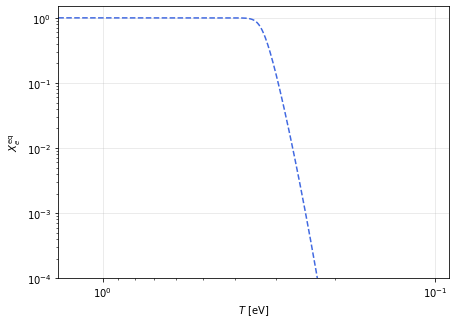

In [34]:
x_grid = np.linspace(10, 150, 600) #corresponds to Temp range 1.36 - 0.09 eV
Xe_saha_root = np.array([solve_saha_root(x) for x in x_grid])

T_grid = eps_0 / x_grid

plt.figure(figsize=(7,5))
plt.loglog(T_grid, Xe_saha_root, ls = "--", color = "royalblue")
plt.xlabel(r"$T$ [eV]")
plt.ylabel(r"$X_e^{\rm eq}$")
plt.xlim(T_grid[0], T_grid[-1])
plt.ylim(1e-4, 1.5)
plt.grid(alpha=0.3)
plt.show()

## H.5.3 d) Solving for freeze-out temperature
We have the following equation that needs to be solved numerically:
$$\frac{x_f}{X^{\rm eq}_e(x_f)} = \lambda,$$
where 
$$\lambda = \frac{2\eta\zeta(3)(\epsilon_0T_0)^{3/2}\sigma_T}{H_0 \sqrt{\Omega_m}\pi^2}.$$


In [38]:
#computing lambda
#Thomson cross section
sigma_T = (8*np.pi/3) * (alpha_em / m_e)**2 
lam = (
    etaB
    * (2*z3/np.pi**2)
    * sigma_T
    * (eps_0*T0_eV)**1.5
    / (H0_eV*np.sqrt(Omega_m))
)
print(lam)

56200.26208968267


In [39]:
def freezeout_equation(x):
    Xe_eq = solve_saha_root(x)
    return x / Xe_eq - lam

x_f = brentq(freezeout_equation, 20, 100)

T_f = eps_0 / x_f
z_f = T_f / T0_eV - 1
X_f = solve_Xe_saha_root(x_f)

print("x_f =", x_f)
print("T_f =", T_f, "eV")
print("z_f =", z_f)
print("X_e(x_f) =", X_f)
print("x_f/lambda =", x_f / lam)

x_f = 55.54609602102382
T_f = 0.24484168959151498 eV
z_f = 1042.364437564504
X_e(x_f) = 0.0009883600886484698
x_f/lambda = 0.000988360088648431


## H.5.3 f) Boltzmann equation
The Boltzmann equation is a first order ODE with the initial condition that for $x\leq1$, $X_e(x)\simeq X^{\rm eq}_e\simeq 1$. The main problem is finding the equilibrium abundance $X^{\rm eq}_{e}(x)$, however, we have just solved for it in part (a). One just needs to replace:
$$\frac{dX_e}{dx} = \frac{\lambda}{x^2} \left[\frac{(X^{\rm eq}_e)^2}{1-X^{\rm eq}_e}\left(1-X_e\right) - (X_e)^2\right]$$ 
by
$$\frac{dX_e}{dx} = \frac{\lambda}{x^2} \left[\frac{1}{A}x^{3/2}e^{-x}\left(1-X_e\right) - (X_e)^2\right]$$

In [24]:
def dXe_dx(x, y):
    Xe = y[0]

    # (Xe_eq)^2 / (1 - Xe_eq)
    equilibrium_factor = (1/A) * x**1.5 * np.exp(-x)

    dXdx = (lam / x**2) * (
        equilibrium_factor * (1 - Xe) - Xe**2
    )

    return [dXdx]

In [26]:
#Initial conditions
T_initial = 1.36  # eV
T_final = 0.09     # eV

x_initial = eps_0 / T_initial
x_final = eps_0 / T_final

Xe_initial = solve_saha_root(x_initial) # = 1


sol = solve_ivp(
    dXe_dx,
    t_span=(x_initial, x_final),
    y0=[Xe_initial],
    method="BDF",
    rtol=1e-8,
    atol=1e-12,
    max_step=0.2,
    dense_output=True
)

if not sol.success:
    print(sol.message)

print("Initial Xe =", Xe_initial)
print("Final Boltzmann Xe =", sol.y[0, -1])

Initial Xe = 1.0
Final Boltzmann Xe = 0.0012851586824696726


In [36]:
#functions for plotting
import matplotlib.ticker as ticker
def T_to_z(T_eV):
    return T_eV / T0_eV - 1

def z_to_T(z):
    return T0_eV * (1 + z)

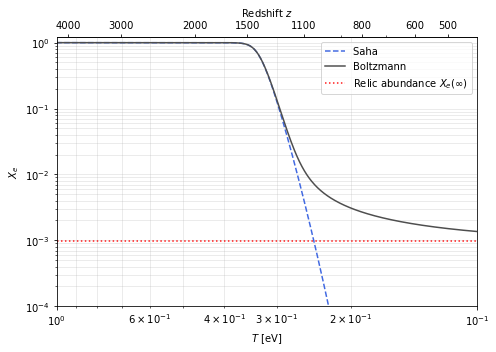

In [41]:
# Plot Saha vs Boltzmann
Xe_boltz = sol.sol(x_grid)[0]

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(T_grid, Xe_saha_root, ls ='--', color = 'royalblue', label=r"Saha ")
ax.loglog(T_grid, Xe_boltz, color = '#4e4e4e', label=r"Boltzmann")
ax.axhline(X_f, ls=":", alpha=0.9, color = 'red',label=rf"Relic abundance $X_e(\infty)$"
)

ax.set_xlabel(r"$T$ [eV]")
ax.set_ylabel(r"$X_e$")

# High temperature on left, low temperature on right
ax.set_xlim(1.0, 0.1)
ax.set_ylim(1e-4, 1.2)

ax.grid(alpha=0.3, which="both")
ax.legend()

secax = ax.secondary_xaxis("top", functions=(T_to_z, z_to_T))
secax.set_xlabel(r"Redshift $z$")
secax.set_xticks([4000, 3000, 2000, 1500, 1100, 800, 600, 500])
secax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda z, pos: f"{z:.0f}"))

plt.tight_layout()
plt.show()

## H.5.4 a) Last scattering temperature
We need to numerically solve 
$$1 = \lambda \int_{x_\ell}^{\infty} X_e(x)x^{-5/2}dx$$
for $x_\ell$. Essentially $\lambda \int_{x_\ell}^{\infty} X_e(x)x^{-5/2}dx =\tau(x_\ell)$ so its just a root finding problem in $x_\ell$.

In [45]:
from scipy.integrate import quad
from scipy.interpolate import interp1d

#interpolate to get a smooth integrable function for X_e
Xe_interp = interp1d(
    x_grid,
    Xe_boltz,
    kind="linear",
    bounds_error=False,
    fill_value=(Xe_boltz[0], Xe_boltz[-1])
)

x_0 = eps_0 / T0_eV

def Xe_of_x(x):
    return float(Xe_interp(x))

def tau_of_x(x_l):
    integrand = lambda xp: Xe_of_x(xp) * xp**(-2.5)
    integral, err = quad(integrand, x_l, x_0, limit=200)
    return lam * integral

# solve tau(x_l) - 1 =0
x_l = brentq(lambda x: tau_of_x(x) - 1, 20, 200)

T_l = eps_0 / x_l
z_l = T_l / T0_eV - 1

print("x_l =", x_l)
print("T_l =", T_l, "eV")
print("z_l =", z_l)

x_l = 46.49460950161339
T_l = 0.2925070270679028 eV
z_l = 1245.4847399539592


## H.5.4 b)  Visibility function
The visibility function can be shown to have the form
$$g(z) = \frac{\lambda}{1+z} X_e(x)x^{-3/2}e^{-\tau(z)}$$  

In [51]:
def x_of_z(z):
    return x_0 / (1 + z)

def Xe(x):
    return np.interp(
        x,
        x_grid,
        Xe_boltz,
        left=Xe_boltz[0],
        right=Xe_boltz[-1]
    )

def dtau_dz(z):
    x = x_of_z(z)
    X = Xe(x)
    return lam * X * x**(-1.5) / (1 + z)

def tau_of_z(z):
    integral, err = quad(dtau_dz, 0, z, limit=200)
    return integral

z_grid = np.linspace(0, 4000, 1000)

tau_z = np.array([tau_of_z(z) for z in z_grid])
dtau_dz_grid = np.array([dtau_dz(z) for z in z_grid])

g_z = np.exp(-tau_z) * dtau_dz_grid

# Last scattering estimate: tau(z_l) = 1
z_l = np.interp(1.0, tau_z, z_grid)
T_l = T0_eV * (1 + z_l)

# Peak of visibility function
z_peak = z_grid[np.argmax(g_z)]
T_peak = T0_eV * (1 + z_peak)

print("z_l from tau=1 =", z_l)
print("T_l =", T_l, "eV")
print("z_peak of g(z) =", z_peak)
print("T_peak =", T_peak, "eV")
print("Integral of g(z) dz =", np.trapz(g_z, z_grid))

<ipython-input-51-23313d2d07a8>:19: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, err = quad(dtau_dz, 0, z, limit=200)


z_l from tau=1 = 1245.4924713175315
T_l = 0.29250884135258776 eV
z_peak of g(z) = 1261.2612612612613
T_peak = 0.2962092331175676 eV
Integral of g(z) dz = 1.0000002496038638


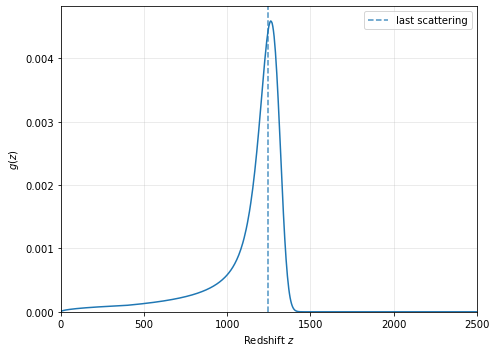

In [54]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(z_grid, g_z)

ax.axvline(z_l, linestyle="--", alpha=0.8,
           label=rf"last scattering")


ax.set_xlabel(r"Redshift $z$")
ax.set_ylabel(r"$g(z)$")

ax.set_xlim(0, 2500)
ax.set_ylim(bottom=0)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()